In [35]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models
import torchvision.transforms.v2 as T
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

In [36]:
# CONFIG — only touch these flags between runs
USE_SUBSET          = True    # True = fast experiment (15%), False = full run
SUBSET_FRACTION     = 0.15
USE_PROXY_MODEL     = True    # True = small proxy,        False = full model
FREEZE_BACKBONE     = True    # True = freeze resnet layers for first phase
UNFREEZE_AT_EPOCH   = 10       # unfreeze backbone after this many epochs
VAL_EVERY_N_EPOCHS  = 3       # validate every N epochs to save time
USE_AMP             = False    # mixed precision — set False if ROCm errors
NUM_EPOCHS          = 30
BATCH_SIZE          = 32
LR                  = 1e-4

folder_path = "../dataset"
types       = ['no', 'sphere', 'vort']   # label 0, 1, 2

try:
    import torch_directml
    device = torch_directml.device()
    print(f"Using device: {device}")
except Exception:
    device = torch.device('cpu')
    print("Using device: CPU")

Using device: privateuseone:0


In [37]:
# 1. AUGMENTATION PIPELINE
#    Only applied to training data, never to validation.
#    Flips + rotation → model learns shape, not position.
#    GaussianNoise    → robustness to sensor/simulation noise.
train_augment = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(degrees=30),
    # T.GaussianNoise(mean=0.0, sigma=0.05),
])

In [38]:
# 2. DATASET
class NPYDataset(Dataset):
    def __init__(self, split, augment=None):
        """
        split   : 'train' or 'val'
        augment : transform pipeline or None
        """
        self.augment = augment
        self.data    = []
        self.labels  = []

        for t in types:
            path  = os.path.join(folder_path, split, t)
            label = types.index(t)

            for file in os.listdir(path):
                arr = np.load(os.path.join(path, file))
                arr = np.transpose(arr, (1, 2, 0))   # (1,150,150) → (150,150,1)
                self.data.append(arr)
                self.labels.append(label)

        self.data   = np.array(self.data,   dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.int64)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx]).permute(2, 0, 1)  # HWC → CHW
        y = torch.tensor(self.labels[idx]).long()

        if self.augment is not None:
            x = self.augment(x)

        return x, y

In [39]:
# ─── Stratified subset helper ─────────────────────────────────────────────────
def get_stratified_subset(dataset, fraction):
    """
    Returns a Subset with `fraction` of data, preserving class ratios.
    e.g. if full data is 40/30/30, subset will also be ~40/30/30.
    """
    labels   = dataset.labels
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=fraction, random_state=42)
    _, idx   = next(splitter.split(np.zeros(len(labels)), labels))
    return Subset(dataset, idx)

In [40]:
# ─── Build datasets ───────────────────────────────────────────────────────────
# Augmentation only on train split
train_dataset = NPYDataset("train", augment=train_augment)
val_dataset   = NPYDataset("val",   augment=None)

if USE_SUBSET:
    train_dataset = get_stratified_subset(train_dataset, SUBSET_FRACTION)
    val_dataset   = get_stratified_subset(val_dataset,   SUBSET_FRACTION)
    print(f"Subset mode  → {len(train_dataset)} train / {len(val_dataset)} val samples")
else:
    print(f"Full dataset → {len(train_dataset)} train / {len(val_dataset)} val samples")

Subset mode  → 4500 train / 1125 val samples


In [41]:
# num_workers=0 intentional — AMD/ROCm multiprocessing issues
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [42]:
# 3. CLASS WEIGHTS
#    Penalises the loss more heavily for getting sphere/vort wrong.
#    Computed from actual label distribution so it's always correct
#    regardless of whether you use a subset or the full dataset.
def get_labels(dataset):
    """Works for both NPYDataset and Subset."""
    if isinstance(dataset, Subset):
        return dataset.dataset.labels[dataset.indices]
    return dataset.labels

train_labels   = get_labels(train_dataset)
class_weights  = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_labels
)
class_weights  = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights → no: {class_weights[0]:.3f} | sphere: {class_weights[1]:.3f} | vort: {class_weights[2]:.3f}")

# criterion = nn.CrossEntropyLoss(weight=class_weights)
criterion = nn.CrossEntropyLoss()

Class weights → no: 1.000 | sphere: 1.000 | vort: 1.000


In [43]:
# 4. MODELS
# ─── Shared backbone builder ──────────────────────────────────────────────────
def make_resnet_backbone(freeze=True):
    """
    Loads ResNet18 with PRETRAINED ImageNet weights.
    
    Even though your data is grayscale (not photos), pretrained weights give
    the backbone a huge head-start on detecting edges, shapes, and textures —
    much better than random init (weights=None).
    
    freeze=True  : backbone is frozen initially; only the head trains.
                   Good for first few epochs — prevents pretrained weights
                   being destroyed by a randomly-initialised head.
    freeze=False : entire network trains end-to-end (full fine-tuning).
    """
    resnet       = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    backbone     = nn.Sequential(*list(resnet.children())[:-1])

    for param in backbone.parameters():
        param.requires_grad = not freeze   # freeze or unfreeze all layers

    return backbone

In [44]:
class FullModel(nn.Module):
    """Full model — use for final training runs (USE_PROXY_MODEL=False)."""
    def __init__(self, freeze_backbone=True):
        super().__init__()
        self.backbone = make_resnet_backbone(freeze=freeze_backbone)
        width         = 128
        self.head     = nn.Sequential(
            nn.Linear(512, width*8), nn.ReLU(), nn.LayerNorm(width*8), nn.Dropout(0.5),
            nn.Linear(width*8, width*4), nn.ReLU(), nn.LayerNorm(width*4), nn.Dropout(0.5),
            nn.Linear(width*4, width),  nn.ReLU(), nn.LayerNorm(width),   nn.Dropout(0.3),
            nn.Linear(width, 3)
        )

    def forward(self, x):
        return self.head(torch.flatten(self.backbone(x), 1))

    def unfreeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = True
        print("  → Backbone unfrozen, full fine-tuning active")


class ProxyModel(nn.Module):
    """
    Lightweight proxy for fast experiments.
    Same input/output as FullModel but much smaller head.
    
    Use to answer directional questions quickly:
      - Does this augmentation help?   → test on proxy (~5 min)
      - Is this LR schedule better?    → test on proxy (~5 min)
    If yes → promote to FullModel for confirmation run (~30–219 min)
    """
    def __init__(self, freeze_backbone=True):
        super().__init__()
        self.backbone = make_resnet_backbone(freeze=freeze_backbone)
        self.head     = nn.Sequential(
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.head(torch.flatten(self.backbone(x), 1))

    def unfreeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = True
        print("  → Backbone unfrozen, full fine-tuning active")

In [45]:
# ─── Instantiate ──────────────────────────────────────────────────────────────
ModelClass = ProxyModel if USE_PROXY_MODEL else FullModel
model      = ModelClass(freeze_backbone=FREEZE_BACKBONE).to(device)
print(f"Model: {'ProxyModel' if USE_PROXY_MODEL else 'FullModel'} | Backbone frozen: {FREEZE_BACKBONE}")



# 5. OPTIMIZER + LR SCHEDULER
#    CosineAnnealingLR: starts at LR and smoothly decays to ~0 by the last
#    epoch. This lets the model take big steps early (exploring) and tiny
#    precise steps late (converging) — much better than a flat LR.
#
#    LR curve shape:   1e-4 ──╮
#                              ╰──────────────╮
#                                              ╰── ~0   (epoch 30)

optimizer = optim.Adam(model.parameters(), lr=LR/100)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

Model: ProxyModel | Backbone frozen: True


C:\Users\dhrut\AppData\Local\Temp\ipykernel_36772\2399294725.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


In [46]:
# 6. TRAINING LOOP
for epoch in range(NUM_EPOCHS):

    # ── Phase switch: unfreeze backbone after UNFREEZE_AT_EPOCH epochs ────────
    # First phase : only the head trains → stabilises the randomly-init head
    #               without wrecking pretrained backbone weights
    # Second phase: full fine-tuning → backbone adapts to your domain
    if FREEZE_BACKBONE and epoch == UNFREEZE_AT_EPOCH:
        model.unfreeze_backbone()
        # Reset optimiser so backbone gets fresh momentum state
        optimizer = optim.Adam(model.parameters(), lr=LR / 10)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - UNFREEZE_AT_EPOCH
        )
        print(f"  → Optimizer reset with lr={LR/10:.1e}")

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = model(X)
            loss    = criterion(outputs, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    scheduler.step()

    current_lr = scheduler.get_last_lr()[0]

    # ── Validation (every N epochs + always on last epoch) ────────────────────
    should_validate = (epoch + 1) % VAL_EVERY_N_EPOCHS == 0 or epoch == NUM_EPOCHS - 1

    if should_validate:
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)

                with torch.cuda.amp.autocast(enabled=USE_AMP):
                    outputs = model(X)
                    loss    = criterion(outputs, y)

                val_loss += loss.item()
                preds     = torch.argmax(outputs, dim=1)
                correct  += (preds == y).sum().item()
                total    += y.size(0)

        val_loss /= len(val_loader)
        val_acc   = correct / total

        print(
            f"Epoch {epoch+1:>3}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"LR: {current_lr:.2e}"
        )
    else:
        print(
            f"Epoch {epoch+1:>3}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"LR: {current_lr:.2e}  (no val)"
        )

C:\Users\dhrut\AppData\Local\Temp\ipykernel_36772\2201213673.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch   1/30 | Train Loss: 692087693.5656 | LR: 9.97e-07  (no val)
Epoch   2/30 | Train Loss: 121612547699296.1406 | LR: 9.89e-07  (no val)


C:\Users\dhrut\AppData\Local\Temp\ipykernel_36772\2201213673.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch   3/30 | Train Loss: 69903452136753.4062 | Val Loss: 431.9440 | Val Acc: 5016115.5564 | LR: 9.76e-07
Epoch   4/30 | Train Loss: 12948560159383.4082 | LR: 9.57e-07  (no val)
Epoch   5/30 | Train Loss: 60770802090267.1016 | LR: 9.33e-07  (no val)
Epoch   6/30 | Train Loss: 28185680460033.0391 | Val Loss: 431.8178 | Val Acc: 0.3333 | LR: 9.05e-07
Epoch   7/30 | Train Loss: 1002293658.9298 | LR: 8.72e-07  (no val)
Epoch   8/30 | Train Loss: 1077660425.7575 | LR: 8.35e-07  (no val)
Epoch   9/30 | Train Loss: 930665510.1172 | Val Loss: 467.6730 | Val Acc: -15924668.6169 | LR: 7.94e-07
Epoch  10/30 | Train Loss: 22846051232235.4844 | LR: 7.50e-07  (no val)
  → Backbone unfrozen, full fine-tuning active
  → Optimizer reset with lr=1.0e-05
Epoch  11/30 | Train Loss: nan | LR: 9.94e-06  (no val)
Epoch  12/30 | Train Loss: nan | Val Loss: nan | Val Acc: 0.3333 | LR: 9.76e-06
Epoch  13/30 | Train Loss: nan | LR: 9.46e-06  (no val)
Epoch  14/30 | Train Loss: nan | LR: 9.05e-06  (no val)
Epoch

In [47]:
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    
    for X, y in val_loader:
        
        X = X.to(device)
        y = y.to(device)

        outputs = model(X)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [48]:
import torch
import numpy as np
import torch.nn.functional as F

model.eval()

test_loss = 0
mae = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for X, y in val_loader:   # use test_loader if you have one

        X = X.to(device)
        y = y.to(device)

        outputs = model(X)

        loss = criterion(outputs, y)
        test_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        mae += torch.abs(preds - y).sum().item()

        total += y.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

test_loss /= len(val_loader)
mae /= total

print(f"Test Loss: {test_loss:.4f}, Test MAE: {mae:.4f}")

Test Loss: nan, Test MAE: 1.0000


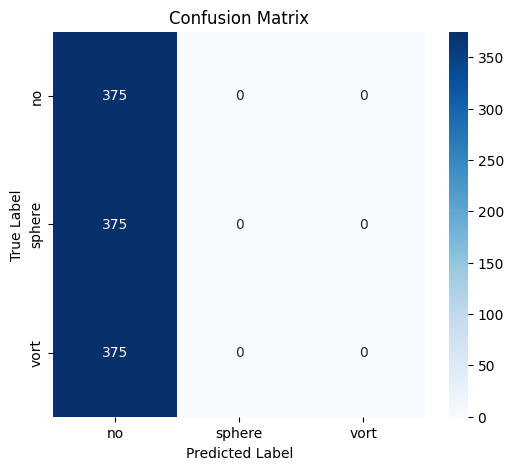

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# convert lists to arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# plot heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["no","sphere","vort"],
    yticklabels=["no","sphere","vort"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()